# 01 · EDA & Data Prep

Two jobs in one notebook:

1. **Prep checklist**: robust load (Mizo has no header), NFC normalization, dedup,
   length filtering, dev/test splits, token-count logging.
2. **EDA** focused on *context*:
   - context length (words + characters) per language pair,
   - how many rows are **one-word / single-token**,
   - **content analysis**: sentiment + topics, to understand what each corpus is *about*.


## 0 · Setup & config

In [1]:
import os, glob, re, unicodedata, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = os.path.abspath(".")
DATA_DIR = os.path.join(ROOT, "category_1")
OUT_DIR  = os.path.join(ROOT, "eda_outputs"); os.makedirs(OUT_DIR, exist_ok=True)
CLEAN_DIR = os.path.join(ROOT, "data_clean"); os.makedirs(CLEAN_DIR, exist_ok=True)
print("data dir:", DATA_DIR)
print("files:", *sorted(os.listdir(DATA_DIR)), sep="\n  ")

data dir: /data/sujay/wmt_2026_indic/category_1
files:
  English-Assamese Training Data 2026.csv
  English-Khasi Training Data 2026.xlsx
  English-Manipuri Training Data 2026.xlsx
  English-Meitei-Mayek Transining Data 2026.xlsx
  English-Mizo Traning Data 2026.xlsx
  English-Nyishi Training Data 2026.xlsx


In [2]:
# key -> (filename substring, has_header, target script)
REGISTRY = {
    "Nyishi":       ("*Nyishi*",        True,  "Latin"),
    "Assamese":     ("*Assamese*",      True,  "Bengali"),
    "Mizo":         ("*Mizo*",          False, "Latin"),       # <- no header row
    "Khasi":        ("*Khasi*",         True,  "Latin"),
    "Manipuri":     ("*Manipuri*",      True,  "Bengali"),     # Meiteilon, Bengali script
    "Meitei-Mayek": ("*Meitei-Mayek*",  True,  "MeiteiMayek"), # Meiteilon, Meitei script
}

def _find(pattern):
    hits = glob.glob(os.path.join(DATA_DIR, pattern))
    if not hits:
        raise FileNotFoundError(pattern)
    return hits[0]

def load_pair(key):
    pattern, has_header, script = REGISTRY[key]
    path = _find(pattern)
    if path.lower().endswith(".csv"):
        df = pd.read_csv(path, header=0 if has_header else None)
    else:
        df = pd.read_excel(path, header=0 if has_header else None)
    df = df.iloc[:, :2]                       # first two cols = (en, target)
    df.columns = ["en", "tgt"]
    df["lang"] = key
    df["script"] = script
    return df

frames = {k: load_pair(k) for k in REGISTRY}
for k, df in frames.items():
    print(f"{k:14s} {len(df):>6,} rows   script={df['script'].iloc[0]}")

Nyishi         60,000 rows   script=Latin
Assamese       54,000 rows   script=Bengali
Mizo           50,000 rows   script=Latin
Khasi          26,000 rows   script=Latin
Manipuri       23,687 rows   script=Bengali
Meitei-Mayek   17,000 rows   script=MeiteiMayek


In [3]:
# Master long-format table (one row per sentence pair, tagged by language)
raw = pd.concat(frames.values(), ignore_index=True)
print("TOTAL raw pairs:", f"{len(raw):,}")
raw.head(4)

TOTAL raw pairs: 230,687


,en,tgt,lang,script
0,weather beaten,og layil tixum tiqhiqnam,Nyishi,Latin
1,weather man,doonyi poolam betambo nyi,Nyishi,Latin
2,weather vane,dooi yinam mam kaan nan,Nyishi,Latin
3,well done,alwb nyipa,Nyishi,Latin


## 1 · Prep checklist

Each step records how many rows it removes, so the cleaning is auditabl.
We keep a `clean` copy and a per-step report; nothing is dropped silently.

In [4]:
def nfc(s):
    return unicodedata.normalize("NFC", s) if isinstance(s, str) else s

def squash_ws(s):
    return re.sub(r"\s+", " ", s).strip() if isinstance(s, str) else s

report = []
def step(df, name):
    report.append((name, len(df)))
    return df

clean = raw.copy()
step(clean, "0. raw")

# (a) NFC normalize + whitespace squash  — critical for Bengali / Meitei Mayek
clean["en"]  = clean["en"].map(nfc).map(squash_ws)
clean["tgt"] = clean["tgt"].map(nfc).map(squash_ws)

# (b) drop nulls / empty either side
clean = clean[(clean["en"].fillna("") != "") & (clean["tgt"].fillna("") != "")]
step(clean, "b. drop empty/null")

# (c) drop rows where source == target (copy-through noise)
clean = clean[clean["en"].str.lower() != clean["tgt"].str.lower()]
step(clean, "c. drop en==tgt")

# (d) exact duplicate pairs (within a language)
clean = clean.drop_duplicates(subset=["lang", "en", "tgt"])
step(clean, "d. drop exact dupes")

# (e) extreme length-ratio filter (char-based, very loose: only kills gross misalignment)
en_c, tg_c = clean["en"].str.len(), clean["tgt"].str.len()
ratio = np.maximum(en_c, tg_c) / np.maximum(np.minimum(en_c, tg_c), 1)
clean = clean[ratio <= 9.0]
step(clean, "e. drop char-ratio>9")

rep = pd.DataFrame(report, columns=["step", "rows_remaining"])
rep["removed"] = rep["rows_remaining"].shift(1) - rep["rows_remaining"]
rep

,step,rows_remaining,removed
0,0. raw,230687,NaN
1,b. drop empty/null,230645,42.0
2,c. drop en==tgt,230601,44.0
3,d. drop exact dupes,218648,11953.0
4,e. drop char-ratio>9,218509,139.0


In [5]:
# Per-language survival after cleaning
surv = (pd.DataFrame({"raw": raw.groupby("lang").size(),
                      "clean": clean.groupby("lang").size()})
          .assign(removed=lambda d: d["raw"] - d["clean"],
                  pct_removed=lambda d: (100*(d.raw-d.clean)/d.raw).round(2)))
surv.loc["TOTAL"] = surv.sum(); surv.loc["TOTAL","pct_removed"] = round(100*surv.loc["TOTAL","removed"]/surv.loc["TOTAL","raw"],2)
surv

,raw,clean,removed,pct_removed
lang,,,,
Assamese,54000.0,52884.0,1116.0,2.07
Khasi,26000.0,25993.0,7.0,0.03
Manipuri,23687.0,23033.0,654.0,2.76
Meitei-Mayek,17000.0,16812.0,188.0,1.11
Mizo,50000.0,49677.0,323.0,0.65
Nyishi,60000.0,50110.0,9890.0,16.48
TOTAL,230687.0,218509.0,12178.0,5.28


## 2 · Context length

Two length proxies (we have no subword tokenizer yet, so these stand in):
- **words** = whitespace token count (meaningful for all six; Bengali & Meitei Mayek use spaces),
- **chars** = character count (fully script-agnostic; the fair cross-language comparison).

`len_ratio` = target chars / source chars . It flags structural expansion/compression per language.

In [6]:
def wcount(s): return len(s.split())
clean = clean.assign(
    en_w  = clean["en"].map(wcount),
    tgt_w = clean["tgt"].map(wcount),
    en_c  = clean["en"].str.len(),
    tgt_c = clean["tgt"].str.len(),
)
clean["len_ratio"] = (clean["tgt_c"] / clean["en_c"]).round(3)

def pctl(s):
    return pd.Series({"mean": s.mean(), "median": s.median(),
                      "p90": s.quantile(.90), "p95": s.quantile(.95),
                      "p99": s.quantile(.99), "max": s.max()})

summary = clean.groupby("lang").agg(
    n=("en","size"),
    en_words_mean=("en_w","mean"),  en_words_p95=("en_w", lambda s:s.quantile(.95)),
    tgt_words_mean=("tgt_w","mean"),tgt_words_p95=("tgt_w",lambda s:s.quantile(.95)),
    en_chars_mean=("en_c","mean"),  tgt_chars_mean=("tgt_c","mean"),
    len_ratio_med=("len_ratio","median"),
).round(2)
summary.to_csv(os.path.join(OUT_DIR,"length_summary.csv"))
summary

,n,en_words_mean,en_words_p95,tgt_words_mean,tgt_words_p95,en_chars_mean,tgt_chars_mean,len_ratio_med
lang,,,,,,,,
Assamese,52884,19.10,31.0,16.26,29.0,94.87,91.61,0.96
Khasi,25993,29.95,54.0,36.49,65.0,138.34,155.41,1.12
Manipuri,23033,18.00,40.0,15.21,33.0,103.65,103.74,1.02
Meitei-Mayek,16812,18.50,36.0,18.02,35.0,112.72,118.08,1.04
Mizo,49677,19.72,37.0,20.99,40.0,94.18,93.91,1.00
Nyishi,50110,5.45,9.0,5.34,9.0,26.18,29.07,1.12


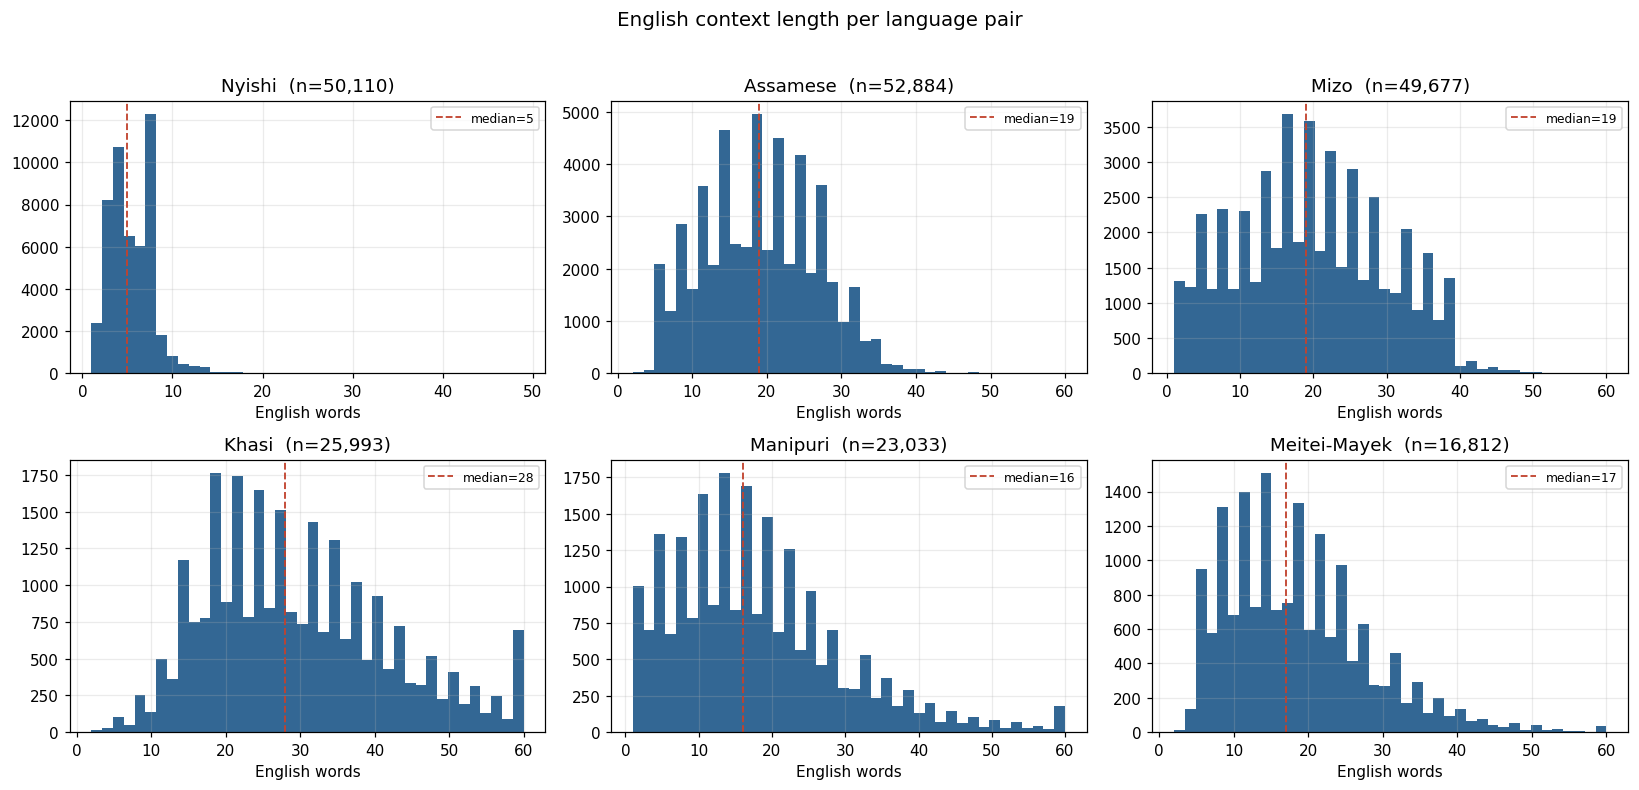

In [7]:
# Distributions of English word-length per language (capped at 60 for readability)
langs = list(REGISTRY)
fig, axes = plt.subplots(2, 3, figsize=(15, 7)); axes = axes.ravel()
for ax, lg in zip(axes, langs):
    d = clean.loc[clean.lang==lg, "en_w"].clip(upper=60)
    ax.hist(d, bins=40, color="#0f4c81", alpha=.85)
    ax.axvline(d.median(), color="#c1432e", ls="--", lw=1.2, label=f"median={d.median():.0f}")
    ax.set_title(f"{lg}  (n={len(d):,})"); ax.set_xlabel("English words"); ax.legend(fontsize=8)
fig.suptitle("English context length per language pair", fontsize=13, y=1.02)
fig.tight_layout(); plt.show()

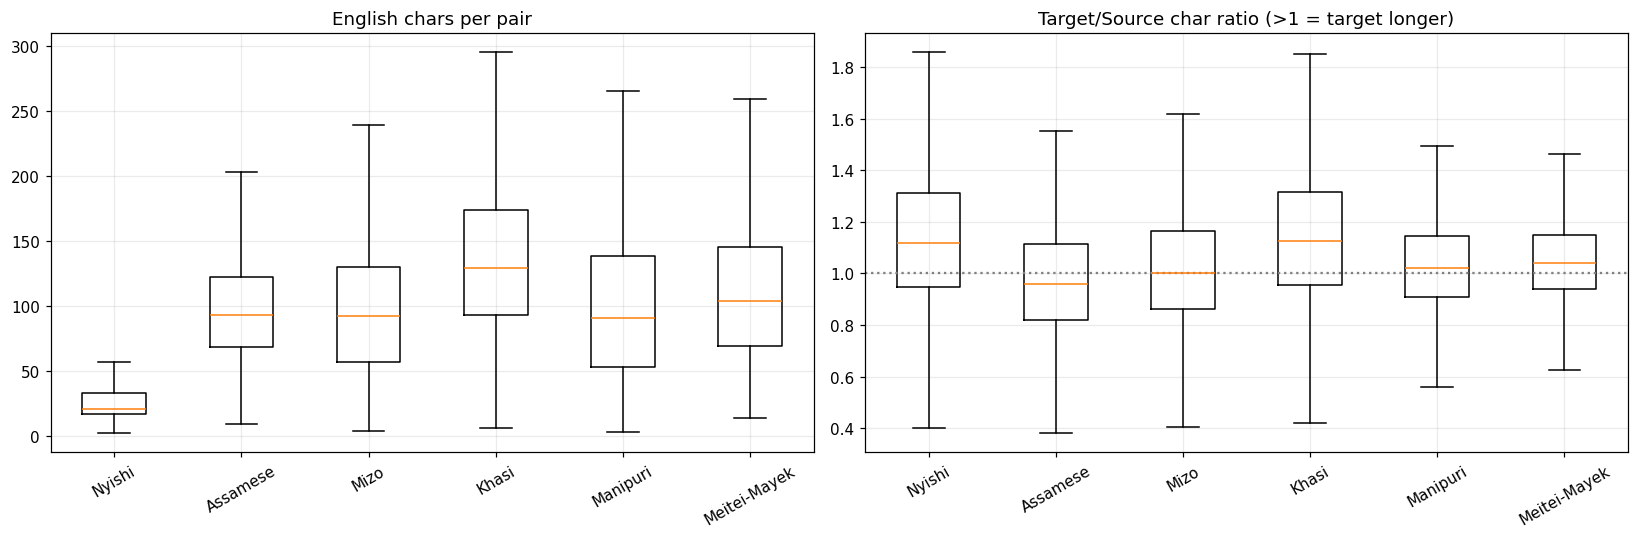

In [8]:
# Cross-language comparison: char-length boxplots (script-agnostic) + len_ratio
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
a1.boxplot([clean.loc[clean.lang==lg,"en_c"].clip(upper=400) for lg in langs],
           labels=langs, showfliers=False); a1.set_title("English chars per pair"); a1.tick_params(axis="x", rotation=30)
a2.boxplot([clean.loc[clean.lang==lg,"len_ratio"].clip(upper=4) for lg in langs],
           labels=langs, showfliers=False); a2.axhline(1, color="grey", ls=":")
a2.set_title("Target/Source char ratio (>1 = target longer)"); a2.tick_params(axis="x", rotation=30)
fig.tight_layout(); plt.show()

## 3 · One-word / single-token rows

Dictionary-style entries (especially **Nyishi**) are short. We quantify how much of each corpus is
effectively a glossary vs. running sentences, this directly affects modeling (a corpus dominated by
1–2 word entries trains very differently).

In [9]:
sw = clean.assign(
    en_1w  = clean.en_w==1,
    tgt_1w = clean.tgt_w==1,
    both_1w= (clean.en_w==1)&(clean.tgt_w==1),
    short  = (clean.en_w<=3)&(clean.tgt_w<=3),
)
g = sw.groupby("lang")
single = pd.DataFrame({
    "n": g.size(),
    "en_1word_%":   (100*g.en_1w.mean()).round(1),
    "tgt_1word_%":  (100*g.tgt_1w.mean()).round(1),
    "both_1word_%": (100*g.both_1w.mean()).round(1),
    "<=3words_both_%": (100*g.short.mean()).round(1),
})
single.to_csv(os.path.join(OUT_DIR,"single_word_stats.csv"))
single

,n,en_1word_%,tgt_1word_%,both_1word_%,<=3words_both_%
lang,,,,,
Assamese,52884,0.0,0.0,0.0,0.0
Khasi,25993,0.0,0.0,0.0,0.0
Manipuri,23033,1.4,1.0,0.9,6.0
Meitei-Mayek,16812,0.0,0.0,0.0,0.0
Mizo,49677,0.0,3.5,0.0,3.8
Nyishi,50110,0.6,0.5,0.3,11.4


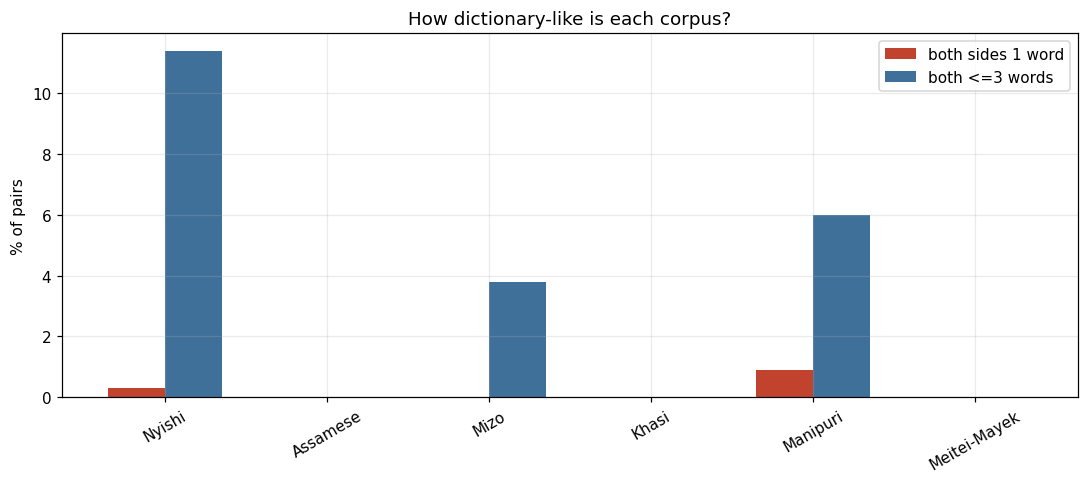

In [10]:
fig, ax = plt.subplots(figsize=(10,4.5))
x = np.arange(len(langs)); w=.35
ax.bar(x-w/2, [single.loc[lg,"both_1word_%"] for lg in langs], w, label="both sides 1 word", color="#c1432e")
ax.bar(x+w/2, [single.loc[lg,"<=3words_both_%"] for lg in langs], w, label="both <=3 words", color="#0f4c81", alpha=.8)
ax.set_xticks(x); ax.set_xticklabels(langs, rotation=30); ax.set_ylabel("% of pairs")
ax.set_title("How dictionary-like is each corpus?"); ax.legend(); fig.tight_layout(); plt.show()

In [11]:
# Peek at the single-word entries that dominate the most glossary-like corpus
top_glossary = single["both_1word_%"].idxmax()
print("Most glossary-like:", top_glossary)
clean[(clean.lang==top_glossary)&(clean.en_w==1)&(clean.tgt_w==1)][["en","tgt"]].head(10)

Most glossary-like: Manipuri


,en,tgt
190064,pallor,পালর
190079,objectives,পান্দমশীং
190122,skimming,স্কিমিং
190169,scope,স্কোপ
190314,education,এজুকেসন
190316,saksham,সকশম
190353,blindness,মিত্তাংবা
190427,agriculture,লৌউ-শিংউ
190436,benefits,কান্নবশীং
190500,scissors,কাটি


## 4 · Content analysis (English side)

### 4a · Sentiment (VADER, lexicon-based)
VADER gives a `compound` score in [-1, 1]. Run on English; read per language to see whether a
corpus skews neutral (technical/dictionary), positive, or negative.

In [12]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

# score a capped sample per language for speed
SAMPLE = 6000
def sample_lang(lg, n=SAMPLE):
    d = clean[clean.lang==lg]
    return d if len(d)<=n else d.sample(n, random_state=42)

sent_rows=[]
for lg in langs:
    d = sample_lang(lg)
    comp = d.en.map(lambda t: vader.polarity_scores(t)["compound"])
    sent_rows.append({"lang":lg, "n_scored":len(d),
                      "mean_compound":round(comp.mean(),3),
                      "%pos":round(100*(comp>0.05).mean(),1),
                      "%neg":round(100*(comp<-0.05).mean(),1),
                      "%neutral":round(100*((comp>=-0.05)&(comp<=0.05)).mean(),1)})
sentiment = pd.DataFrame(sent_rows).set_index("lang")
sentiment.to_csv(os.path.join(OUT_DIR,"sentiment.csv"))
sentiment

,n_scored,mean_compound,%pos,%neg,%neutral
lang,,,,,
Nyishi,6000,0.035,24.0,17.0,59.0
Assamese,6000,0.111,41.1,20.9,38.0
Mizo,6000,0.092,37.9,22.4,39.8
Khasi,6000,0.079,40.2,26.5,33.2
Manipuri,6000,0.104,37.8,16.8,45.4
Meitei-Mayek,6000,0.140,41.3,16.6,42.0


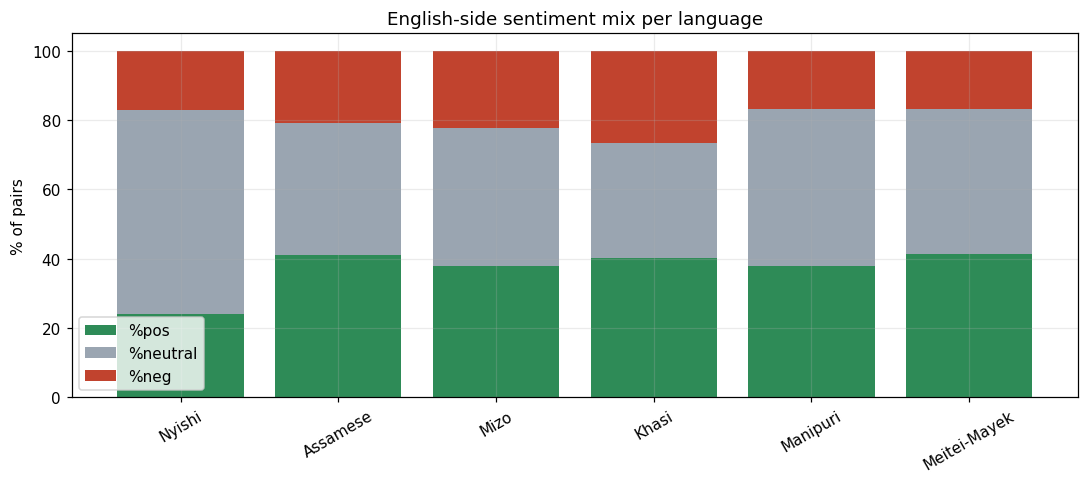

In [13]:
fig, ax = plt.subplots(figsize=(10,4.5))
b = sentiment[["%pos","%neutral","%neg"]]
bottom=np.zeros(len(b))
for col,c in zip(["%pos","%neutral","%neg"],["#2e8b57","#9aa5b1","#c1432e"]):
    ax.bar(b.index, b[col], bottom=bottom, label=col, color=c); bottom+=b[col].values
ax.set_ylabel("% of pairs"); ax.set_title("English-side sentiment mix per language"); ax.legend(); plt.xticks(rotation=30); fig.tight_layout(); plt.show()

### 4b · Topics & vocabulary (TF-IDF + NMF)
For each language we fit a small **NMF topic model** on the English side and print the top terms per
topic: a fast read on *what the corpus talks about*. We also flag **Bible/scripture register**
(thee/thou/thy/LORD/...) to quantify the religious-domain skew noted for Mizo & Khasi.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

EN_STOP = "english"
def top_topics(texts, n_topics=5, n_top=8):
    vec = TfidfVectorizer(stop_words=EN_STOP, max_df=0.6, min_df=5,
                          token_pattern=r"[A-Za-z][A-Za-z]+")
    X = vec.fit_transform(texts)
    if X.shape[1] < n_topics:
        return []
    nmf = NMF(n_components=n_topics, init="nndsvda", max_iter=300, random_state=42).fit(X)
    vocab = np.array(vec.get_feature_names_out())
    return [", ".join(vocab[row.argsort()[::-1][:n_top]]) for row in nmf.components_]

for lg in langs:
    print(f"\n=== {lg} — top topics (English side) ===")
    for i, terms in enumerate(top_topics(clean.loc[clean.lang==lg, "en"]), 1):
        print(f"  T{i}: {terms}")


=== Nyishi — top topics (English side) ===
  T1: tom, mary, did, isn, didn, doesn, said, help
  T2: don, know, think, did, didn, need, let, understand
  T3: want, didn, doesn, come, don, talk, help, just
  T4: ll, come, think, home, help, soon, tomorrow, look
  T5: like, doesn, don, looks, look, feel, mary, going

=== Assamese — top topics (English side) ===
  T1: unto, lord, said, saying, ye, came, moses, israel
  T2: shall, ye, come, man, say, eat, land, day
  T3: thou, thy, thee, shalt, hast, thine, art, said
  T4: god, jehovah, jesus, people, love, man, christ, life
  T5: minister, prime, modi, shri, narendra, india, said, today

=== Mizo — top topics (English side) ===
  T1: yahweh, israel, people, children, moses, saying, day, house
  T2: shall, make, offering, priest, holy, eat, unclean, land
  T3: god, lord, jehovah, christ, good, jesus, love, spirit
  T4: said, son, man, father, jesus, king, don, lord
  T5: come, let, don, know, time, home, good, day

=== Khasi — top topics (

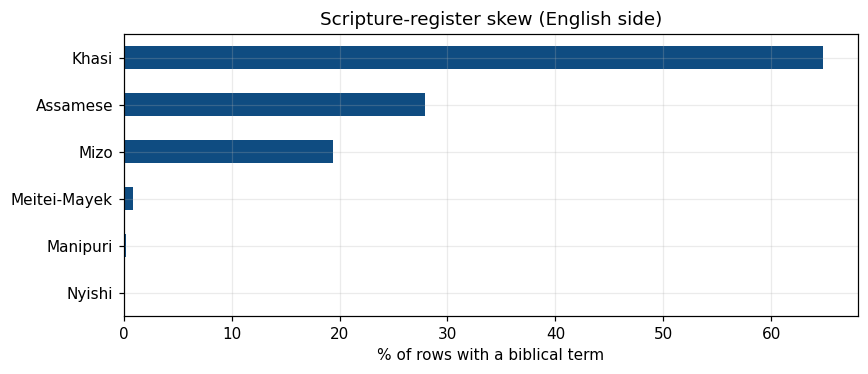

Khasi           64.8
Assamese        27.9
Mizo            19.4
Meitei-Mayek     0.9
Manipuri         0.2
Nyishi           0.1
Name: %rows_with_bible_term, dtype: float64

In [15]:
# Bible / archaic-register detector
BIBLE = {"thee","thou","thy","thine","ye","hath","shalt","unto","lord","god","israel",
         "jesus","christ","verily","behold","saith","heaven","sin","lord's"}
def bible_frac(texts):
    hits = texts.str.lower().str.findall(r"[a-z']+").map(lambda ws: any(w in BIBLE for w in ws))
    return round(100*hits.mean(), 1)

dom = pd.Series({lg: bible_frac(clean.loc[clean.lang==lg,"en"]) for lg in langs}, name="%rows_with_bible_term")
ax = dom.sort_values().plot(kind="barh", figsize=(8,3.5), color="#0f4c81")
ax.set_title("Scripture-register skew (English side)"); ax.set_xlabel("% of rows with a biblical term"); plt.tight_layout(); plt.show()
dom.sort_values(ascending=False)

## 5 · Dev/test splits + save cleaned data

Deterministic split per language (seed=42). **Placeholder splits** if WMT ships an official
dev/test set, swap these out and never report on a private split. Cleaned data and splits
are written to `data_clean/<lang>/`.

In [16]:
def split_lang(d, dev_frac=0.05, test_frac=0.05, seed=42, cap=2000):
    d = d.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = len(d)
    n_dev  = min(cap, int(round(n*dev_frac)))
    n_test = min(cap, int(round(n*test_frac)))
    test = d.iloc[:n_test]; dev = d.iloc[n_test:n_test+n_dev]; train = d.iloc[n_test+n_dev:]
    return train, dev, test

cols = ["en","tgt"]
rows=[]
for lg in langs:
    d = clean[clean.lang==lg]
    tr, dv, te = split_lang(d)
    outdir = os.path.join(CLEAN_DIR, lg); os.makedirs(outdir, exist_ok=True)
    for name, part in [("train",tr),("dev",dv),("test",te)]:
        part[cols].to_csv(os.path.join(outdir, f"{name}.tsv"), sep="\t", index=False)
    rows.append({"lang":lg,"train":len(tr),"dev":len(dv),"test":len(te)})
splits = pd.DataFrame(rows).set_index("lang"); splits.loc["TOTAL"]=splits.sum()
print("written to", CLEAN_DIR)
splits

written to /data/sujay/wmt_2026_indic/data_clean


,train,dev,test
lang,,,
Nyishi,46110,2000,2000
Assamese,48884,2000,2000
Mizo,45677,2000,2000
Khasi,23393,1300,1300
Manipuri,20729,1152,1152
Meitei-Mayek,15130,841,841
TOTAL,199923,9293,9293


## 6 · Auto-summary

Programmatic recap so the notebook self-documents its findings when re-run.

In [17]:
print("CONTEXT-LENGTH (median English words):")
for lg in langs:
    print(f"  {lg:14s} {clean.loc[clean.lang==lg,'en_w'].median():>5.0f} words   "
          f"({single.loc[lg,'both_1word_%']:>4.1f}% are 1-word pairs)")
print("\nMost glossary-like:", single['both_1word_%'].idxmax(),
      f"({single['both_1word_%'].max()}% single-word pairs)")
print("Most scripture-heavy:", dom.idxmax(), f"({dom.max()}% rows w/ biblical term)")
print("Most positive sentiment:", sentiment['mean_compound'].idxmax(),
      f"(compound={sentiment['mean_compound'].max()})")
print("\nArtifacts: eda_outputs/*.csv  +  data_clean/<lang>/{train,dev,test}.tsv")

CONTEXT-LENGTH (median English words):
  Nyishi             5 words   ( 0.3% are 1-word pairs)
  Assamese          19 words   ( 0.0% are 1-word pairs)
  Mizo              19 words   ( 0.0% are 1-word pairs)
  Khasi             28 words   ( 0.0% are 1-word pairs)
  Manipuri          16 words   ( 0.9% are 1-word pairs)
  Meitei-Mayek      17 words   ( 0.0% are 1-word pairs)

Most glossary-like: Manipuri (0.9% single-word pairs)
Most scripture-heavy: Khasi (64.8% rows w/ biblical term)
Most positive sentiment: Meitei-Mayek (compound=0.14)

Artifacts: eda_outputs/*.csv  +  data_clean/<lang>/{train,dev,test}.tsv
